Industrial Production Forecasting Using Machine Learning

Category: Supervised Machine Learning – Regression

Project Goal: Develop a machine learning system that estimates the production output of manufacturing equipment based on operational conditions such as machine temperature, operating pressure, cycle duration, material characteristics, and other production-related parameters. The predicted output can help industries improve machine utilization, optimize production planning, and identify unusual performance.

Dataset: manufacturing_dataset_1000_samples.csv — Contains 1,000 manufacturing records with multiple input variables and Parts_Per_Hour as the prediction target.

Project Pipeline:
Data Collection & Understanding → Data Inspection → Data Cleaning → Missing Value Treatment → Duplicate Removal → Outlier Detection & Treatment → Feature Creation → Exploratory Data Analysis → Data Preprocessing → Train-Test Split → Linear Regression Model → Compare Regression Models → Hyperparameter Optimization → Model Evaluation → Performance Visualization → Save Trained Model → Build FastAPI Application → Docker Deployment

In [1]:
# Import required libraries for data analysis, visualization
# preprocessing, model building, and evaluation.
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

step 1: Load Dataset and  Data Inspection

In [2]:
# Load the manufacturing dataset
df = pd.read_csv(r"C:\Users\shrav\Downloads\manufacturing_dataset_1000_samples.csv")

# Display the shape of the dataset
print("Shape:", df.shape)

# Display the first five rows
df.head()

Shape: (1000, 19)


,Timestamp,Injection_Temperature,Injection_Pressure,Cycle_Time,Cooling_Time,Material_Viscosity,Ambient_Temperature,Machine_Age,Operator_Experience,Maintenance_Hours,Shift,Machine_Type,Material_Grade,Day_of_Week,Temperature_Pressure_Ratio,Total_Cycle_Time,Efficiency_Score,Machine_Utilization,Parts_Per_Hour
0,2023-01-01 00:00:00,221.0,136.0,28.7,13.6,375.5,28.0,3.8,11.2,64,Evening,Type_B,Economy,Thursday,1.625,42.3,0.063,0.510,36.5
1,2023-01-01 01:00:00,213.3,128.9,34.5,14.0,215.8,22.6,6.8,6.3,58,Night,Type_A,Standard,Wednesday,1.655,48.5,0.037,0.389,29.9
2,2023-01-01 02:00:00,222.8,115.9,19.9,9.5,307.0,25.3,4.2,9.6,47,Day,Type_A,Standard,Monday,1.922,29.4,0.061,0.551,56.9
3,2023-01-01 03:00:00,233.3,105.3,39.2,13.1,137.8,26.0,9.2,8.6,49,Evening,Type_A,Premium,Saturday,2.215,52.3,0.054,0.293,31.0
4,2023-01-01 04:00:00,212.2,125.5,45.0,9.9,298.2,23.6,6.2,23.0,49,Night,Type_B,Premium,Monday,1.691,54.9,0.145,0.443,15.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Timestamp                   1000 non-null   object 
 1   Injection_Temperature       1000 non-null   float64
 2   Injection_Pressure          1000 non-null   float64
 3   Cycle_Time                  1000 non-null   float64
 4   Cooling_Time                1000 non-null   float64
 5   Material_Viscosity          980 non-null    float64
 6   Ambient_Temperature         980 non-null    float64
 7   Machine_Age                 1000 non-null   float64
 8   Operator_Experience         980 non-null    float64
 9   Maintenance_Hours           1000 non-null   int64  
 10  Shift                       1000 non-null   object 
 11  Machine_Type                1000 non-null   object 
 12  Material_Grade              1000 non-null   object 
 13  Day_of_Week                 1000 n

In [7]:
# Display dataset shape
print(df.shape)

# Display data types
print(df.dtypes)

# Display summary statistics
df.describe()

(1000, 19)
Timestamp                      object
Injection_Temperature         float64
Injection_Pressure            float64
Cycle_Time                    float64
Cooling_Time                  float64
Material_Viscosity            float64
Ambient_Temperature           float64
Machine_Age                   float64
Operator_Experience           float64
Maintenance_Hours               int64
Shift                          object
Machine_Type                   object
Material_Grade                 object
Day_of_Week                    object
Temperature_Pressure_Ratio    float64
Total_Cycle_Time              float64
Efficiency_Score              float64
Machine_Utilization           float64
Parts_Per_Hour                float64
dtype: object


,Injection_Temperature,Injection_Pressure,Cycle_Time,Cooling_Time,Material_Viscosity,Ambient_Temperature,Machine_Age,Operator_Experience,Maintenance_Hours,Temperature_Pressure_Ratio,Total_Cycle_Time,Efficiency_Score,Machine_Utilization,Parts_Per_Hour
count,1000.000000,1000.000000,1000.00000,1000.00000,980.000000,980.000000,1000.000000,980.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,215.315900,116.075000,35.85170,11.92320,251.630714,22.941224,7.855900,30.795204,50.580000,1.885852,47.737000,0.192688,0.356844,29.298100
std,11.995507,14.667246,8.35349,2.30429,73.348695,2.773712,3.900798,27.684769,16.014558,0.274323,8.671153,0.173839,0.195610,11.955497
min,180.000000,80.000000,16.30000,8.00000,104.600000,18.000000,1.000000,1.000000,26.000000,1.286000,24.600000,0.006000,0.001000,5.000000
25%,207.200000,105.900000,28.80000,10.27500,200.900000,20.800000,4.700000,9.800000,45.000000,1.683750,41.000000,0.061000,0.193000,17.500000
50%,215.300000,115.950000,36.85000,11.90000,242.700000,22.900000,7.900000,22.100000,50.000000,1.849500,48.550000,0.139000,0.355500,28.200000
75%,222.800000,125.925000,45.00000,13.50000,295.300000,25.100000,11.100000,43.425000,55.000000,2.044250,55.300000,0.274000,0.520000,38.000000
max,300.000000,150.000000,60.00000,19.90000,1000.000000,28.000000,15.000000,120.000000,500.000000,2.843000,64.900000,0.840000,0.755000,68.600000


In [4]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Injection_Temperature,1000.0,215.315900,11.995507,180.000,207.20000,215.3000,222.80000,300.000
Injection_Pressure,1000.0,116.075000,14.667246,80.000,105.90000,115.9500,125.92500,150.000
Cycle_Time,1000.0,35.851700,8.353490,16.300,28.80000,36.8500,45.00000,60.000
Cooling_Time,1000.0,11.923200,2.304290,8.000,10.27500,11.9000,13.50000,19.900
Material_Viscosity,980.0,251.630714,73.348695,104.600,200.90000,242.7000,295.30000,1000.000
Ambient_Temperature,980.0,22.941224,2.773712,18.000,20.80000,22.9000,25.10000,28.000
Machine_Age,1000.0,7.855900,3.900798,1.000,4.70000,7.9000,11.10000,15.000
Operator_Experience,980.0,30.795204,27.684769,1.000,9.80000,22.1000,43.42500,120.000
Maintenance_Hours,1000.0,50.580000,16.014558,26.000,45.00000,50.0000,55.00000,500.000
Temperature_Pressure_Ratio,1000.0,1.885852,0.274323,1.286,1.68375,1.8495,2.04425,2.843


step 2 : CHECK MISSING VALUES

In [5]:
# Check the number of missing values in each column.

print("Missing values:")
print(df.isnull().sum())

Missing values:
Timestamp                      0
Injection_Temperature          0
Injection_Pressure             0
Cycle_Time                     0
Cooling_Time                   0
Material_Viscosity            20
Ambient_Temperature           20
Machine_Age                    0
Operator_Experience           20
Maintenance_Hours              0
Shift                          0
Machine_Type                   0
Material_Grade                 0
Day_of_Week                    0
Temperature_Pressure_Ratio     0
Total_Cycle_Time               0
Efficiency_Score               0
Machine_Utilization            0
Parts_Per_Hour                 0
dtype: int64


step 3: HANDLE MISSING VALUES

In [40]:
numeric_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

df[numeric_columns] = df[numeric_columns].fillna(
    df[numeric_columns].median()
)

print(df.isnull().sum())

Injection_Temperature         0
Injection_Pressure            0
Cycle_Time                    0
Cooling_Time                  0
Material_Viscosity            0
Ambient_Temperature           0
Machine_Age                   0
Operator_Experience           0
Maintenance_Hours             0
Temperature_Pressure_Ratio    0
Total_Cycle_Time              0
Efficiency_Score              0
Machine_Utilization           0
Parts_Per_Hour                0
Hour                          0
Day                           0
Month                         0
Shift_Evening                 0
Shift_Night                   0
Machine_Type_Type_B           0
Machine_Type_Type_C           0
Material_Grade_Premium        0
Material_Grade_Standard       0
Day_of_Week_Monday            0
Day_of_Week_Saturday          0
Day_of_Week_Sunday            0
Day_of_Week_Thursday          0
Day_of_Week_Tuesday           0
Day_of_Week_Wednesday         0
dtype: int64


step 4 : REMOVE DUPLICATES

In [42]:
print("Duplicates:", df.duplicated().sum())

df = df.drop_duplicates()

print("New Shape:", df.shape)

Duplicates: 0
New Shape: (1000, 29)


TIME FEATURE ENGINEERING

In [48]:
print("Time-related features:")
print(df[["Hour", "Day", "Month"]].head())

Time-related features:
       Hour       Day     Month
0 -1.655100 -1.372703 -0.586588
1 -1.510373 -1.372703 -0.586588
2 -1.365646 -1.372703 -0.586588
3 -1.220919 -1.372703 -0.586588
4 -1.076191 -1.372703 -0.586588


In [108]:
#Exploratory Data Analysis
print("\nStatistical Summary")
print(df.describe())


Statistical Summary
       Injection_Temperature  Injection_Pressure    Cycle_Time  Cooling_Time  \
count           1.000000e+03        1.000000e+03  1.000000e+03  1.000000e+03   
mean            5.684342e-17       -1.936229e-16  6.972201e-16 -5.995204e-16   
std             1.000500e+00        1.000500e+00  1.000500e+00  1.000500e+00   
min            -2.945567e+00       -2.460793e+00 -2.341714e+00 -1.703416e+00   
25%            -6.769169e-01       -6.940697e-01 -8.445845e-01 -7.156325e-01   
50%            -1.326160e-03       -8.526655e-03  1.195667e-01 -1.007322e-02   
75%             6.242208e-01        6.719004e-01  1.095695e+00  6.846313e-01   
max             7.063184e+00        2.314134e+00  2.892250e+00  3.463450e+00   

       Material_Viscosity  Ambient_Temperature   Machine_Age  \
count        1.000000e+03         1.000000e+03  1.000000e+03   
mean         3.730349e-16         1.193712e-15  2.025047e-16   
std          1.000500e+00         1.000500e+00  1.000500e+00   
mi

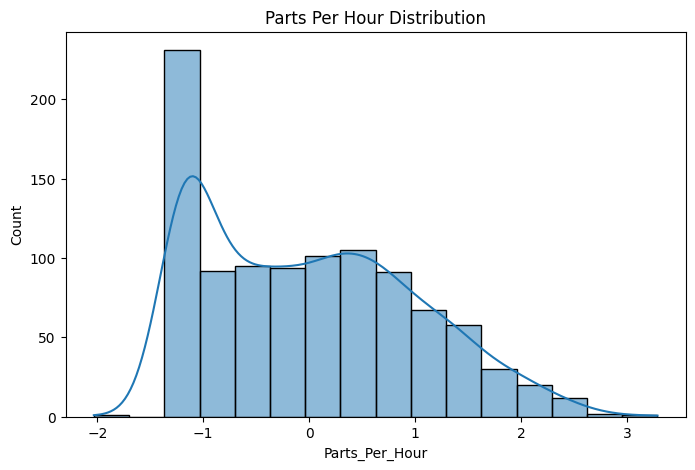

In [110]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["Parts_Per_Hour"],
    kde=True
)

plt.title("Parts Per Hour Distribution")

plt.show()


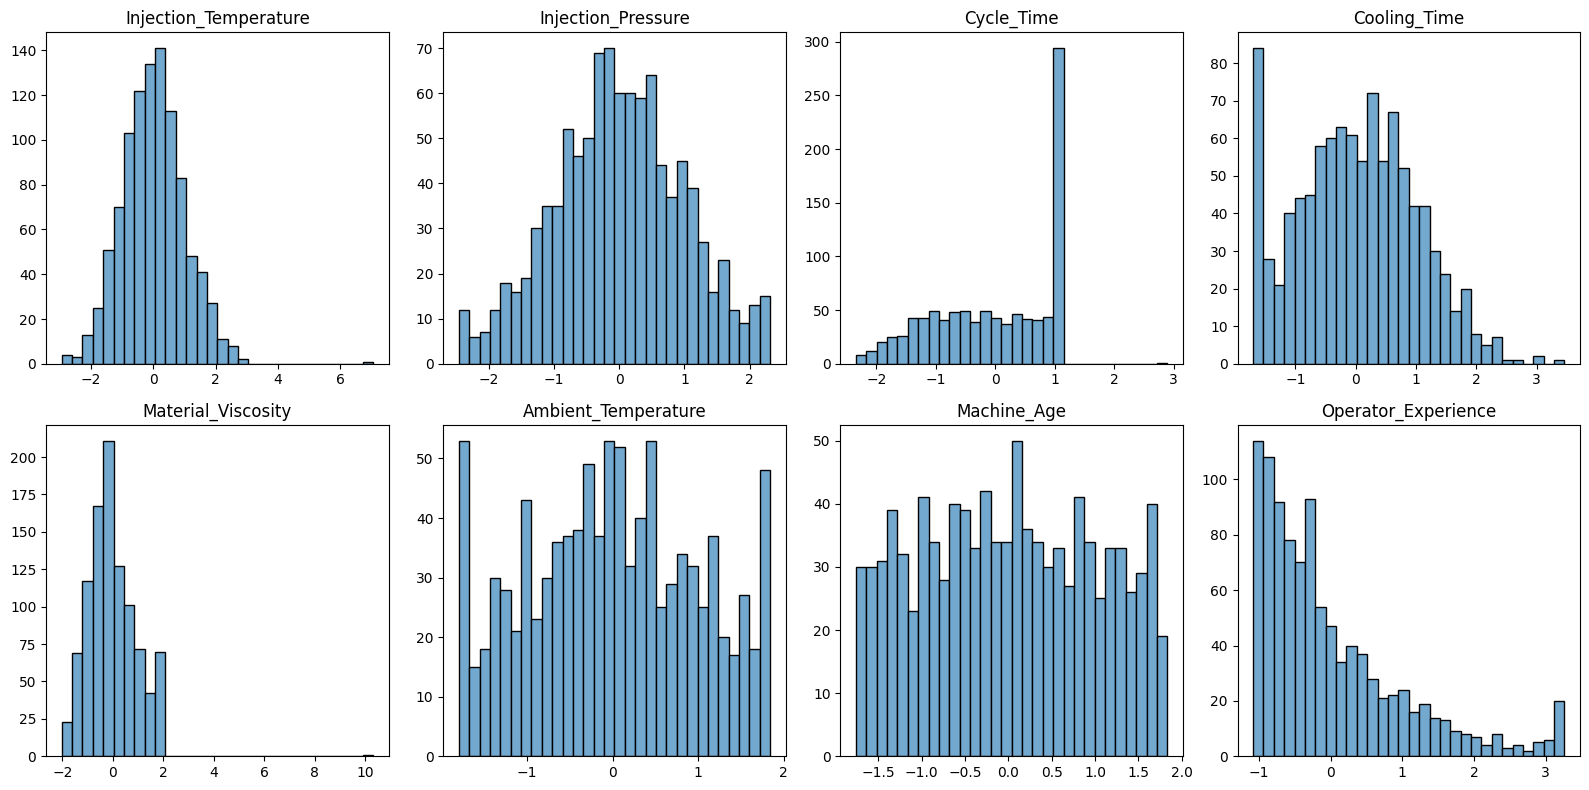

In [111]:
# Plot 8 numerical variables separately

numeric_cols = df.select_dtypes(include=np.number).columns[:8]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for ax, col in zip(axes.flat, numeric_cols):
    ax.hist(df[col], bins=30, edgecolor="black", color="#74a9cf")
    ax.set_title(col)

plt.tight_layout()
plt.show()

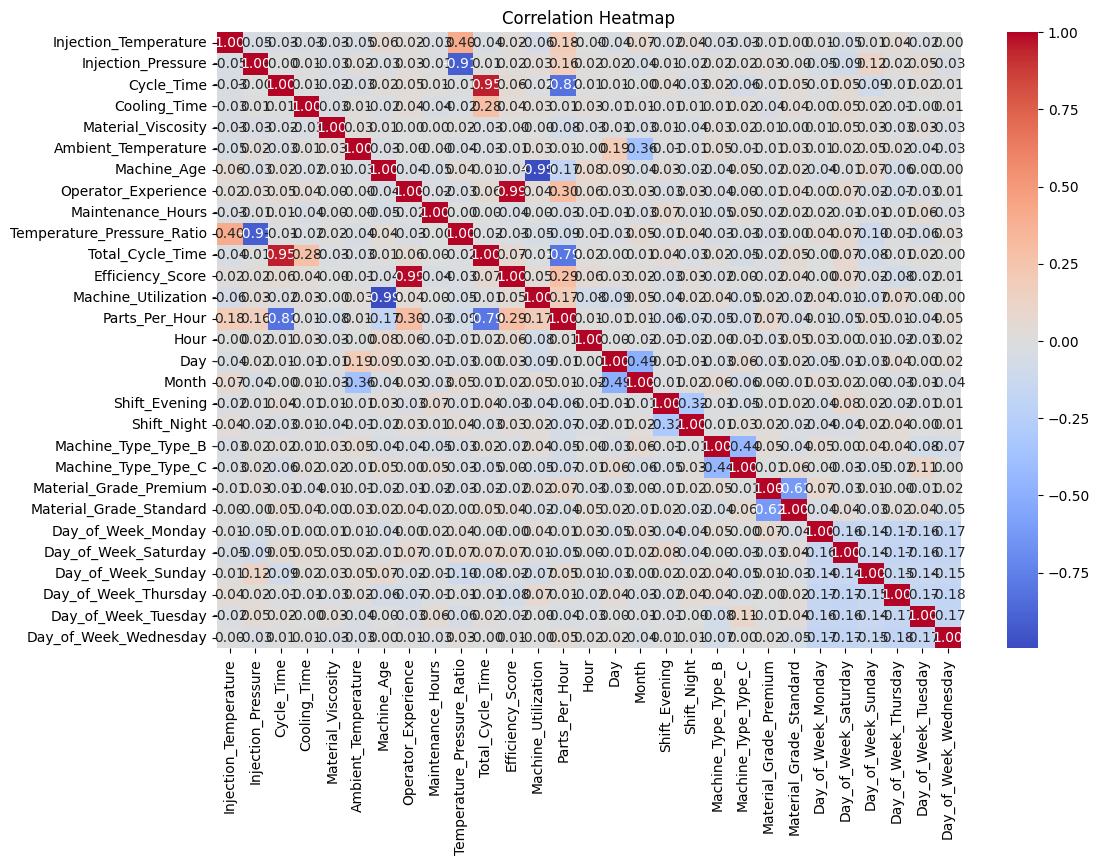

In [112]:
# Find relationships between numerical variables
corr_matrix = df.corr(numeric_only=True)

# Display correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


DEFINE FEATURES AND TARGET

In [92]:
# Create X by removing the target column
X = df.drop(
    "Parts_Per_Hour",
    axis=1
)

# Create y using the target column
y = df["Parts_Per_Hour"]

# Display input features
print("Features (X):")
print(X.head())

# Display target values
print("\nTarget (y):")
print(y.head())

# Display the shape of input features
print("\nFeature Shape:", X.shape)

# Display the shape of target variable
print("Target Shape:", y.shape)

Features (X):
   Injection_Temperature  Injection_Pressure  Cycle_Time  Cooling_Time  \
0               0.474090            1.359149   -0.856562      0.728050   
1              -0.168139            0.874835   -0.161894      0.901726   
2               0.624221           -0.011937   -1.910541     -1.052130   
3               1.499987           -0.734998    0.401027      0.510955   
4              -0.259886            0.642910    1.095695     -0.878454   

   Material_Viscosity  Ambient_Temperature  Machine_Age  Operator_Experience  \
0            1.708997             1.843582    -1.040282            -0.708301   
1           -0.491176            -0.124033    -0.270824            -0.887005   
2            0.765278             0.859775    -0.937688            -0.766653   
3           -1.565775             1.114836     0.344743            -0.803123   
4            0.644042             0.240341    -0.424715            -0.277951   

   Maintenance_Hours  Temperature_Pressure_Ratio  ...  Machi

TRAIN TEST SPLIT

In [93]:
# Split the dataset into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Display training data shape
print("Training Features:", X_train.shape)

# Display testing data shape
print("Testing Features:", X_test.shape)

# Display training target shape
print("Training Target:", y_train.shape)

# Display testing target shape
print("Testing Target:", y_test.shape)


Training Features: (800, 28)
Testing Features: (200, 28)
Training Target: (800,)
Testing Target: (200,)


 LINEAR REGRESSION PIPELINE

In [94]:
# Create a pipeline for preprocessing and model training
linear_pipeline = Pipeline([

    # Scale the input features
    ("scaler", StandardScaler()),

    # Apply Linear Regression model
    ("model", LinearRegression())

])

print("Pipeline created successfully!")

Pipeline created successfully!


TRAIN MODEL

In [95]:
# Train the pipeline using training data
linear_pipeline.fit(
    X_train,
    y_train
)

# Display training completion message
print("Linear Regression trained successfully!")

Linear Regression trained successfully!


 PREDICTION

In [68]:
y_pred = linear_pipeline.predict(
    X_test
)

MODEL EVALUATION

In [96]:
# Calculate Mean Absolute Error
mae = mean_absolute_error(
    y_test,
    y_pred
)

# Calculate Mean Squared Error
mse = mean_squared_error(
    y_test,
    y_pred
)

# Calculate Root Mean Squared Error
rmse = np.sqrt(mse)

# Calculate R2 Score
r2 = r2_score(
    y_test,
    y_pred
)

# Display evaluation results
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 0.22824237533196523
MSE : 0.08630483350725669
RMSE: 0.2937768430412048
R2 Score: 0.9055614878191497


 MODEL COMPARISON

In [98]:
# Import regression models
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Create different regression models
models = {

    # Basic Linear Regression
    "Linear Regression": LinearRegression(),

    # Ridge Regression
    "Ridge Regression": Ridge(),

    # Lasso Regression
    "Lasso Regression": Lasso()

}

# Create an empty list to store results
results = []


# Loop through each model
for name, model in models.items():

    # Create pipeline with scaling and model
    pipeline = Pipeline([

        # Scale the input features
        ("scaler", StandardScaler()),

        # Apply the selected model
        ("model", model)

    ])

    # Train the model
    pipeline.fit(
        X_train,
        y_train
    )

    # Make predictions on test data
    prediction = pipeline.predict(
        X_test
    )

    # Calculate RMSE
    rmse_value = np.sqrt(
        mean_squared_error(
            y_test,
            prediction
        )
    )

    # Calculate R2 Score
    r2_value = r2_score(
        y_test,
        prediction
    )

    # Store model results
    results.append([
        name,
        rmse_value,
        r2_value
    ])



# Convert results into a DataFrame
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "RMSE",
        "R2 Score"
    ]
)

# Display model comparison
print(results_df)

               Model      RMSE  R2 Score
0  Linear Regression  0.293777  0.905561
1   Ridge Regression  0.293654  0.905641
2   Lasso Regression  0.965556 -0.020161


In [ ]:
HYPERPARAMETER TUNING - RIDGE REGRESSION

In [100]:
# Import GridSearchCV
from sklearn.model_selection import GridSearchCV

# Create Ridge Regression pipeline
ridge_pipeline = Pipeline([

    # Scale the features
    ("scaler", StandardScaler()),

    # Apply Ridge Regression
    ("model", Ridge())
])


# Define hyperparameter values
param_grid = {

    # Different alpha values to test
    "model__alpha": [
        0.01,
        0.1,
        1,
        10,
        100
    ]
}


# Create GridSearchCV
grid_search = GridSearchCV(

    # Ridge pipeline
    ridge_pipeline,

    # Hyperparameter combinations
    param_grid,

    # 5-fold cross-validation
    cv=5,

    # Use R2 Score for selecting the best model
    scoring="r2"
)


# Train GridSearchCV
grid_search.fit(
    X_train,
    y_train
)


# Print the best alpha value
print("Best Parameters:")
print(grid_search.best_params_)

# Print the best cross-validation R2 score
print("\nBest Cross-Validation R2 Score:")
print(grid_search.best_score_)

Best Parameters:
{'model__alpha': 0.01}

Best Cross-Validation R2 Score:
0.915562925154202


FINAL MODEL

In [101]:
# Select the best model found by GridSearchCV
final_model = grid_search.best_estimator_

# Make predictions using the final model
final_pred = final_model.predict(
    X_test
)

# Display first 10 predictions
print("Final Model Predictions:")
print(final_pred[:10])

Final Model Predictions:
[-0.77516879  1.29053366  0.42100611  0.88451354 -0.91537338 -0.72341059
  0.36842711 -1.26108832 -0.11308518  0.24329721]


FINAL EVALUATION

In [102]:
# Calculate Mean Absolute Error
final_mae = mean_absolute_error(
    y_test,
    final_pred
)

# Calculate Root Mean Squared Error
final_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        final_pred
    )
)

# Calculate R2 Score
final_r2 = r2_score(
    y_test,
    final_pred
)

# Display final model performance
print("\nFINAL MODEL")

print("MAE :", final_mae)

print("RMSE:", final_rmse)

print("R2 Score:", final_r2)



FINAL MODEL
MAE : 0.22824526629726472
RMSE: 0.2937753762011361
R2 Score: 0.9055624308876804


ACTUAL VS PREDICTED

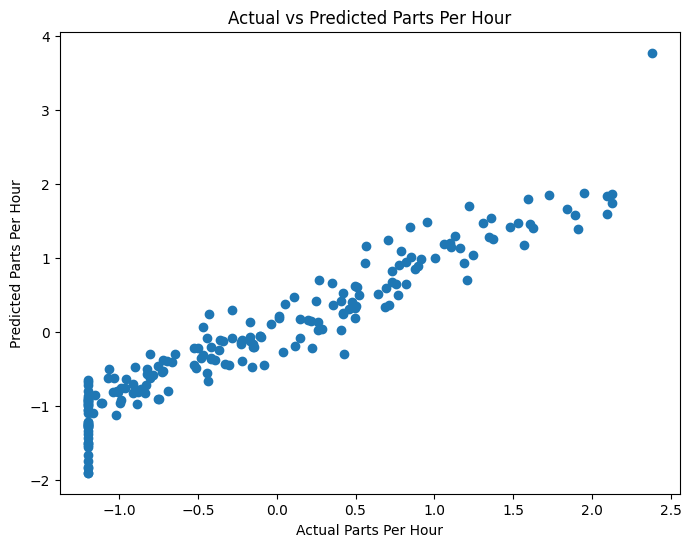

In [103]:
# Create the plot
plt.figure(figsize=(8, 6))

# Plot actual values against predicted values
plt.scatter(
    y_test,
    final_pred
)

# Set X-axis label
plt.xlabel("Actual Parts Per Hour")

# Set Y-axis label
plt.ylabel("Predicted Parts Per Hour")

# Set plot title
plt.title("Actual vs Predicted Parts Per Hour")

# Display the plot
plt.show()



SAVE MODEL

In [105]:
# Save the trained final model
joblib.dump(
    final_model,
    "manufacturing_output_model.pkl"
)

# Display confirmation message
print("Model saved successfully!")

Model saved successfully!


LOAD MODEL

In [106]:
# Load the saved model
model = joblib.load(
    "manufacturing_output_model.pkl"
)

# Display confirmation message
print("Model loaded successfully!")

Model loaded successfully!


TEST SAVED MODEL

In [107]:
# Generate predictions using the saved model
prediction = model.predict(
    X_test
)

# Display the first 10 predictions
print("Predictions:")

print(prediction[:10])

Predictions:
[-0.77516879  1.29053366  0.42100611  0.88451354 -0.91537338 -0.72341059
  0.36842711 -1.26108832 -0.11308518  0.24329721]
